In [29]:
from fairness_metric_utils import *
from penalty_utils import *
from weight_utils import *

# Load Data

In [ ]:
dataset_path = 'AdultCensus/adult-preprocessed-2race-2age-2edu.csv'
df=pd.read_csv(dataset_path)

fair_metrics=['FPN', 'PPE'] #'GFA', 'PPA', 'FPR', 'PPE', 'FPA', 'OAE', 'EOP', 'FNP', 'FPP'
protected_attributes =['age', 'sex', 'race', 'edu']
mapping= {
    'age':{
        0: 'young',
        1: 'adult'
    },
    'edu':{
        0: 'low-edu',
        1: 'high-edu'
    },
    'sex':{
        0: 'female',
        1: 'male'
    },
    'race':{
        0: 'Amer-Black-Other',
        1: 'Asian-White'
    }
}
feature_cols= df.columns
target_variable = 'income'
target_variable_labels= ['0','1']
df.head()

,age,edu,marital.status,relationship,race,sex,capital.gain,capital.loss,hours.per.week,income
0,1,0,6,1,1,0,0,4356,40,0
1,1,0,6,1,1,0,0,4356,18,0
2,1,1,6,4,0,0,0,4356,40,0
3,1,0,0,4,1,0,0,3900,40,0
4,1,1,5,3,1,0,0,3900,40,0


# Compute Fairness
An addition is made to compute_fairness_metrics. A count_group dictionary is made specifying the subgroup and the "length" which is TN + FP + FN + TP

## Classifier and Predictions

## Functions

### Variables Overview
Y = **income** (target variable column)

X = **input features** to train the model -- dataset without target column

Data split: Training 70%, Validation 15%, Testing 15%

**Pipeline:**
1. Model 1: Fit on training → Predict on validation → Compute fairness metrics, penalty, weights
2. Model 1: Fit on training → Predict on test → Compute fairness metrics, penalty FOR COMPARISON PURPOSES
2. Model 2: Fit on training (with weights) → Predict on test

### Utils Overview

Confusion matrix computed to obtain TP, FP, TN, FN 

Performance metrics computed (fairness_metrics_utils): Precision, Recall, Accuracy, F1

Compute the previous functions, plus the confusion matrix for...

## Build the dictionaries 

In the form {Subgroup: data}

# Model 1: Fit on train, predict on validation, compute metrics

`fairness_metrics_dict` - Dictionary holding the fairness metrics over all attribute combinations and the supported fairness metrics # TODO: only do it for sex-race, sex, race attributes to simplify runtime


In [85]:
pairs_dict= {}
fairness_metrics_dict= {}
X_train = {}
y_train = {}
X_val = {}    # Validation set (used for computing fairness metrics, weights)
y_val = {}
y_pred = {}   # Predictions on validation set
X_test = {}   # Test set (unseen, used for final evaluation)
y_test = {}
group_counts= {}
s= []
model_baseline= {}

for i in range(1,len(protected_attributes)+1):
  pairs_dict[i] = ['-'.join(pair) for pair in combinations(protected_attributes, i)]
#print(pairs_dict)

for i in range(1, len(protected_attributes)+1):
  df=pd.read_csv(dataset_path)
  for sensible_attribute in pairs_dict[i]:
    s = sensible_attribute.split('-')
    print(s)
    if len(s)>1:
      df=pd.read_csv(dataset_path)
      df[sensible_attribute] = reduce(lambda x, y: x.astype(str) + y.astype(str), [df[col] for col in s])
      df = df.drop(columns=s)
    
    # Updated to include X_test and y_test
    (y_train[sensible_attribute], X_train[sensible_attribute], 
     X_val[sensible_attribute], y_val[sensible_attribute], y_pred[sensible_attribute],
     X_test[sensible_attribute], y_test[sensible_attribute],
     fairness_metrics_dict[sensible_attribute], group_counts[sensible_attribute], model_baseline[sensible_attribute]) = get_test_pred_fairness(
        df, target_variable, sensible_attribute, fair_metrics, dataset_path, mapping, target_variable_labels)

['age']
age
Precision: 0.7212475633528265, Recall: 0.6192468619246861, Accuracy: 0.8482800982800983, F1: 0.6663665015758667
['sex']
sex
Precision: 0.7212475633528265, Recall: 0.6192468619246861, Accuracy: 0.8482800982800983, F1: 0.6663665015758667
['race']
race
Precision: 0.7212475633528265, Recall: 0.6192468619246861, Accuracy: 0.8482800982800983, F1: 0.6663665015758667
['edu']
edu
Precision: 0.7212475633528265, Recall: 0.6192468619246861, Accuracy: 0.8482800982800983, F1: 0.6663665015758667
['age', 'sex']
age-sex
Precision: 0.7214076246334311, Recall: 0.6175732217573222, Accuracy: 0.8480753480753481, F1: 0.6654643823264202
['age', 'race']
age-race
Precision: 0.7179236043095005, Recall: 0.6133891213389121, Accuracy: 0.8464373464373465, F1: 0.6615523465703971
['age', 'edu']
age-edu
Precision: 0.7232580961727183, Recall: 0.6167364016736402, Accuracy: 0.8484848484848485, F1: 0.6657633242999097
['sex', 'race']
sex-race
Precision: 0.7216796875, Recall: 0.6184100418410042, Accuracy: 0.84828

# Model 1: Fit on train, predict on test, compute metrics on test

`fairness_metrics_ontest` - Dictionary holding the fairness metrics over sex-race, sex, race attributes for the supported fairness metrics

`cm` - Confusion matrix calculated with library

`cm_dict` - Confusion matrix mapped into a dictionary, distributing the cells of `cm` for each class

In [86]:
# Prepare df with sex-race column for evaluation
sensible_attribute = 'sex-race'
s = sensible_attribute.split('-')
df = pd.read_csv(dataset_path)
df[sensible_attribute] = reduce(lambda x, y: x.astype(str) + y.astype(str), [df[col] for col in s])
df = df.drop(columns=s)

# Evaluate Model 1 (baseline) on TEST set
y_pred_test_ontest, performance_ontest, fairness_metrics_ontest, counts_ontest, cm_dict, cm = evaluate_model_on_test(
    model_baseline['sex-race'], df, 'sex-race', 
    X_test['sex-race'], y_test['sex-race'],
    fair_metrics, mapping, dataset_path
)


# print(f"Performance: Precision={performance_baseline[0]:.4f}, Recall={performance_baseline[1]:.4f}, Accuracy={performance_baseline[2]:.4f}, F1={performance_baseline[3]:.4f}")
# print(f"Fairness Metrics: {fairness_baseline}")
print(f"Group Counts: {counts_ontest}")

Precision: 0.7469194312796209, Recall: 0.6533996683250415, Accuracy: 0.8597748208802457, F1: 0.6970367094206104
Group Counts: {'01': 1323, '00': 287, '11': 2992, '10': 283}


In [87]:
# Compute fairness metrics on TEST set for individual attributes (sex, race) 
# to enable penalty calculation on test set

attrs_for_penalty = ['sex', 'race', 'sex-race']
df_original = pd.read_csv(dataset_path)

fairness_metrics_ontest_full = {}
counts_ontest_full = {}

# Create combined column
df_combined = df_original.copy()
individual_attrs = sensible_attribute.split('-')
df_original[sensible_attribute] = reduce(lambda x, y: x.astype(str) + y.astype(str), 
                                          [df_combined[col] for col in individual_attrs])

for attr in attrs_for_penalty:
    sensible_indexes = df_original[attr].loc[list(X_test[attr].index)]
    cm_dict_attr = compute_cm_group(
        df_original, attr, sensible_indexes,
        y_pred_test_ontest, y_test[attr], X_test[attr], target_variable_labels
    )
    
    fairness_metrics_ontest_full[attr] = {}
    for m in fair_metrics:
        fairness_metrics_ontest_full[attr][m], counts_ontest_full[attr] = \
            compute_fairness_metrics_and_counts(cm_dict_attr, m, attr, mapping, dataset_path)

print("Fairness metrics on TEST set (for penalty calculation):")
for attr in attrs_for_penalty:
    print(f"  {attr}: {fairness_metrics_ontest_full[attr]}")

Fairness metrics on TEST set (for penalty calculation):
  sex: {'FPN': {0: 0.1896551724137931, 1: 0.4305799648506151}, 'PPE': {0: 0.015384615384615385, 1: 0.10893730546909737}, 'GFA': {0: 0.0670807453416149, 1: 0.28916030534351145}, 'PPA': {0: 0.7962962962962963, 1: 0.7412882787750792}, 'FPR': {0: 0.2037037037037037, 1: 0.2587117212249208}, 'FPA': {0: 0.06258322237017311, 1: 0.13917525773195877}, 'OAE': {0: 0.9279503105590062, 1: 0.8262595419847328}, 'EOP': {0: 0.5222222222222223, 1: 0.3157894736842105}, 'FNP': {0: 0.058385093167701865, 1: 0.09893129770992366}, 'FPP': {0: 0.013664596273291925, 1: 0.07480916030534351}}
  race: {'FPN': {1: 0.410459587955626, 0: 0.14814814814814814}, 'PPE': {1: 0.08131868131868132, 0: 0.016194331983805668}, 'GFA': {1: 0.23568945538818076, 0: 0.06666666666666667}, 'PPA': {1: 0.7453294001966568, 0: 0.7894736842105263}, 'FPR': {1: 0.25467059980334317, 0: 0.21052631578947367}, 'FPA': {1: 0.11279563371740449, 0: 0.08646616541353383}, 'OAE': {1: 0.8537659327925

# Model 1: Compute penalties on TEST

In [90]:
# Compute BASELINE penalties on TEST set (Model 1 predictions)
penalties_ontest_baseline = {}

for m in fair_metrics:
    # penalty_harm, penalty_geom, penalty_arith = compute_penalty_2(
    #     fairness_metrics_ontest_full, df_combined, 'sex', 'race', m
    # )
    penalties_ontest_baseline[m] = compute_penalty_2(fairness_metrics_ontest_full, df_combined, 'sex', 'race', m)
    
    # penalties_ontest_baseline[m] = {
    #     'harmonic': penalty_harm
    #     'geometric': penalty_geom,
    #     'arithmetic': penalty_arith
    # }
    # print(f"\nBaseline penalties on TEST set ({m}):")
    # print(f"  Harmonic:   {penalty_harm}")
    # print(f"  Geometric:  {penalty_geom}")
    # print(f"  Arithmetic: {penalty_arith}")

In [35]:
cm

array([[3412,  267],
       [ 418,  788]])

In [36]:
cm_dict

{'01': array([[1144,   22],
        [  80,   77]]),
 '00': array([[264,   0],
        [ 14,   9]]),
 '11': array([[1782,  237],
        [ 292,  681]]),
 '10': array([[222,   8],
        [ 32,  21]])}

In [37]:
fairness_metrics_ontest

{'FPN': {'01': 0.21568627450980393,
  '00': 0,
  '11': 0.44801512287334594,
  '10': 0.2},
 'PPE': {'01': 0.018867924528301886,
  '00': 0,
  '11': 0.11738484398216939,
  '10': 0.034782608695652174}}

In [38]:
fairness_metrics_dict['sex-race']['FPN']

{'01': 0.2564102564102564,
 '00': 0.25,
 '11': 0.42387543252595156,
 '10': 0.21052631578947367}

# Model 1: Compute Penalties on VALIDATION

Every subgroup and attribute combination, for each metric.

In [97]:
values= {}
penalties_across_metrics= {}
for m in fair_metrics:
  print(m)
  df=pd.read_csv(dataset_path)
  actual_values= {}
  predicted_values= {}
  penalties= {}
  for i in range(1, len(protected_attributes)+1):
    for sensible_attribute in pairs_dict[i]:
      s = sensible_attribute.split('-')
      #print(sensible_attribute)
      if len(s)==2:
        s1, s2 = sensible_attribute.split('-')
        # Build dictionary for attribute combinations. Form {attributes: {subgroup: value, s: v, s: v, ...}...}
        actual_values[sensible_attribute], predicted_values[sensible_attribute] = actual_predicted_values_2(fairness_metrics_dict, df,s1, s2, m)
        print(s1, s2, actual_values[sensible_attribute], predicted_values[sensible_attribute])

        # Build dictionary for penalty calculation of each attribute and subgroup combination. 
        penalties[sensible_attribute] = compute_penalty(actual_values[sensible_attribute], predicted_values[sensible_attribute])
        print(penalties[sensible_attribute])
      elif len(s)==3:
        s1, s2, s3 = sensible_attribute.split('-')
        actual_values[sensible_attribute], predicted_values[sensible_attribute] = actual_predicted_values_3(fairness_metrics_dict, df,s1, s2, s3, m)
        print(s1, s2, s3, actual_values[sensible_attribute], predicted_values[sensible_attribute])
        penalties[sensible_attribute] = compute_penalty(actual_values[sensible_attribute], predicted_values[sensible_attribute])
        print(penalties[sensible_attribute])
      elif len(s)==4:
        s1, s2, s3, s4 = sensible_attribute.split('-')
        actual_values[sensible_attribute], predicted_values[sensible_attribute] = actual_predicted_values_4(fairness_metrics_dict, df,s1, s2, s3, s4, m)
        print(s1, s2, s3, s4, actual_values[sensible_attribute], predicted_values[sensible_attribute])
        penalties[sensible_attribute] = compute_penalty(actual_values[sensible_attribute], predicted_values[sensible_attribute])
        print(penalties[sensible_attribute])
      
      values[m]= [actual_values, predicted_values]
      penalties_across_metrics[m]= penalties # The penalties dictionary itself didn't include m before
print(penalties)

#print(values['FPP'])


FPN
age sex {'00': 0.24324324324324326, '01': 0.16111111111111112, '10': 0.25287356321839083, '11': 0.5136986301369864} {'00': 0.20911528150134048, '01': 0.2505100884153253, '10': 0.32671957671957674, '11': 0.4404252864320202}
{'00': -16.320166320166326, '01': 35.68677727501256, '10': 22.602261622225324, '11': -16.63695204663865}
age race {'00': 0, '01': 0.1848341232227488, '10': 0.23076923076923078, '11': 0.4897959183673469} {'00': 0.19485385960529603, '01': 0.24756779134754706, '10': 0.2931924743308208, '11': 0.43141101499167833}
{'00': 100.0, '01': 25.339995878837826, '10': 21.290875116786037, '11': -13.533475351062794}
age edu {'00': 0.12698412698412698, '01': 0.1830065359477124, '10': 0.09444444444444444, '11': 0.6656976744186046} {'00': 0.13697560975609754, '01': 0.26727171698462676, '10': 0.17923564824768864, '11': 0.49500338524035203}
{'00': 7.294351738796177, '01': 31.527907998496232, '10': 47.307109178454205, '11': -34.48345895561317}
sex race {'00': 0.25, '01': 0.25641025641

In [40]:
m = 'FPN'  
print(penalties_across_metrics[m]['sex-race'])
print(fairness_metrics_dict['sex-race'][m])
print(group_counts['sex-race'])

{'00': -8.749999999999988, '01': 16.480862133036045, '10': 25.05675954592364, '11': -4.572201228919415}
{'01': 0.2564102564102564, '00': 0.25, '11': 0.42387543252595156, '10': 0.21052631578947367}
{'01': 1403, '00': 246, '11': 2937, '10': 298}


# Model 2: Fit on training (with weights), predict on test

In [41]:
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier

In [42]:
def model_with_sample_weights(X_train, y_train, X_val, y_val, X_test, y_test, weights, model_type='GB'):
  # Note: weights were computed on test set, then propagated to the training set based on group membership.
  
  
  if model_type=='GB':
    # Model 2: Fit on training, predict on val (unseen)
    model = GradientBoostingClassifier(random_state = 1234).fit(X_train['sex-race'], y_train['sex-race'], sample_weight=weights)
    y_pred_on_test = model.predict(X_test['sex-race'])
  elif model_type=='RF':
    model = RandomForestClassifier(random_state = 1234).fit(X_train['sex-race'], y_train['sex-race'], sample_weight=weights)
    y_pred_on_test = model.predict(X_test['sex-race'])
  elif model_type=='XGB':
    import xgboost as xgb
    # Convert string combinations to numeric codes for BOTH train and val
    X_train_numeric = X_train['sex-race'].copy()
    X_train_numeric['sex-race'] = X_train_numeric['sex-race'].astype('category').cat.codes
    
    X_test_numeric = X_test['sex-race'].copy()
    X_test_numeric['sex-race'] = X_test_numeric['sex-race'].astype('category').cat.codes
    
    model = xgb.XGBClassifier(random_state = 1234, eval_metric='logloss')
    model.fit(X_train_numeric, y_train['sex-race'], sample_weight=weights)
    y_pred_on_test = model.predict(X_test_numeric)

  sensible_indexes = X_test['sex-race']['sex-race'].loc[list(X_test['sex-race'].index)]
  cm = confusion_matrix(y_test['sex-race'], y_pred_on_test, labels=[0,1])
  print(cm)

  precision, recall, accuracy, f1_score = performance_metrics(y_test['sex-race'], y_pred_on_test)

  fairness_metrics_dict_after={}
  count_groups_after= {}
  # Compute fairness metrics on VAL set predictions
  cm_dict = compute_cm_group(df, 'sex-race', sensible_indexes, y_pred_on_test, y_test['sex-race'], X_test['sex-race'], [0,1])
  for m in fair_metrics:
    fairness_metrics_dict_after[m], count_groups_after = compute_fairness_metrics_and_counts(cm_dict, m, 'sex-race', mapping, dataset_path)

  # print("Fairness metrics after:", fairness_metrics_dict_after)
  for k in fairness_metrics_dict_after[m].keys():
    a = fairness_metrics_dict[sensible_attribute][m][k]
    b = fairness_metrics_dict_after[m][k]
    diff = b - a
    # print(f"Group {k}: before={a}, after={b}, diff={diff}")

  return precision, recall, accuracy, f1_score

# Computing Weights - Functions

# Generalizing for multiple fairness metrics

Note: flat group and nromal weight computation both may use FPN metric but yield different weights because they are computing different penalties. 

Note: flat group is currently able to calculate for multiple fairness metrics. Meanwhile, normal weight calculation is not because penalties_across_metrics currently only holds  values for the m metric. 

# Calculating and Implementing weights

Three ways of calculating the weights, all implemented with the same function above (Model 2)

### $w_i = 1 + \lambda * Penalty(g_i) * \frac{|g_i|}{|G_{max}|} $

In [43]:
sensible_attribute = 'sex-race'
s = sensible_attribute.split('-')
df=pd.read_csv(dataset_path)
df[sensible_attribute] = reduce(lambda x, y: x.astype(str) + y.astype(str), [df[col] for col in s])
df = df.drop(columns=s)

In [108]:
def compute_weights_sized(lambda_=1.0):

    train_df = X_train['sex-race'].copy()
    weights_for_training = np.ones(len(train_df))
    m = 'PPE'

    # # Calculate average weight per group from validation set
    # df['weight'] = weights
    group_counts2 = train_df['sex-race'].value_counts().to_dict() # |g_i| number of attribute value combinations for subgroup "group_col"
    max_group_size = max(group_counts2.values()) # |G_max| subgroup with the highest number of attribute value combinations (dimension)

    group_weights = {
        group: max(0.01, 1 + lambda_ * (penalty / 100) * (group_counts2.get(group, 1)/max_group_size))
        for group, penalty in penalties_across_metrics[m]['sex-race'].items()
    }


    # Assign weights to training samples based on their group
    for i, (idx, row) in enumerate(train_df.iterrows()):
        group = row['sex-race']
        if group in group_weights:
            weights_for_training[i] = group_weights[group]

    print(f"Training samples: {len(weights_for_training)}, Unique weights per group: {group_weights}")
    weights_sized = weights_for_training

    return weights_sized

In [109]:
lambdas = [0.1, 1.0, 5.0, 10.0]
weights_sized_dict = {}

for lambda_ in lambdas:
    weights_sized = compute_weights_sized(lambda_)
    weights_sized_dict[lambda_] = weights_sized
    print(f"Lambda: {lambda_}")

Training samples: 22792, Unique weights per group: {'00': 1.0053213821040463, '01': 1.0127124739194775, '10': 1.0007087409508215, '11': 0.9739442042568826}
Lambda: 0.1
Training samples: 22792, Unique weights per group: {'00': 1.0532138210404633, '01': 1.1271247391947743, '10': 1.0070874095082143, '11': 0.7394420425688253}
Lambda: 1.0
Training samples: 22792, Unique weights per group: {'00': 1.2660691052023172, '01': 1.6356236959738717, '10': 1.0354370475410712, '11': 0.01}
Lambda: 5.0
Training samples: 22792, Unique weights per group: {'00': 1.5321382104046344, '01': 2.2712473919477434, '10': 1.0708740950821425, '11': 0.01}
Lambda: 10.0


In [ ]:
# Keep a single standard weight for other parts of the notebook
weights_notsized = compute_weights_sized(5.0)

In [ ]:
# Model 2 performance
model_with_sample_weights(X_train, y_train, X_val, y_val, X_test, y_test, weights_sized)

[[3449  230]
 [ 452  754]]
Precision: 0.766260162601626, Recall: 0.6252072968490879, Accuracy: 0.860388945752303, F1: 0.6885844748858447


(0.766260162601626, 0.6252072968490879, 0.860388945752303, 0.6885844748858447)

### $w_i = 1 + \lambda * Penalty(g_i) $

In [135]:
def compute_weights_notsized(lambda_=5.0):
    train_df = X_train['sex-race'].copy()
    weights_for_training = np.ones(len(train_df))
    m = 'FPN'

    # lambda_ = 10.0
    group_weights = {
        group: max(0.01, 1 + lambda_ * (penalty / 100))
        for group, penalty in penalties_across_metrics[m]['sex-race'].items()
    }


    # Assign weights to training samples based on their group
    for i, (idx, row) in enumerate(train_df.iterrows()):
        group = row['sex-race']
        if group in group_weights:
            weights_for_training[i] = group_weights[group]

    print(f"Training samples: {len(weights_for_training)}, Unique weights per group: {group_weights}")
    weights_notsized = weights_for_training

    return weights_notsized



In [136]:
lambdas = [0.1, 1.0, 5.0, 10.0]
weights_notsized_dict = {}
weights_notsized_performanceL_dict = {}
for lambda_ in lambdas:
    weights_notsized = compute_weights_notsized(lambda_)
    weights_notsized_dict[lambda_] = weights_notsized
    print(f"Lambda: {lambda_}")
    # weights_notsized_performanceL_dict[lambda_] = model_with_sample_weights(X_train, y_train, X_val, y_val, X_test, y_test, weights_notsized)

Training samples: 22792, Unique weights per group: {'00': 0.99125, '01': 1.0164808621330361, '10': 1.0250567595459237, '11': 0.9954277987710806}
Lambda: 0.1
Training samples: 22792, Unique weights per group: {'00': 0.9125000000000001, '01': 1.1648086213303603, '10': 1.2505675954592363, '11': 0.9542779877108059}
Lambda: 1.0
Training samples: 22792, Unique weights per group: {'00': 0.5625000000000007, '01': 1.8240431066518021, '10': 2.252837977296182, '11': 0.7713899385540293}
Lambda: 5.0
Training samples: 22792, Unique weights per group: {'00': 0.12500000000000133, '01': 2.6480862133036043, '10': 3.505675954592364, '11': 0.5427798771080585}
Lambda: 10.0


In [48]:
# Keep a single standard weight for other parts of the notebook
weights_notsized = compute_weights_notsized(5.0)

Training samples: 22792, Unique weights per group: {'00': 3.966776950647918, '01': 2.4147753232966824, '10': 1.3680488588878168, '11': 0.01}


In [80]:
# Model 2 performance
model_with_sample_weights(X_train, y_train, X_val, y_val, X_test, y_test, weights_notsized)

[[3452  227]
 [ 448  758]]
Precision: 0.7695431472081218, Recall: 0.6285240464344942, Accuracy: 0.8618219037871033, F1: 0.6919214970333181


(0.7695431472081218,
 0.6285240464344942,
 0.8618219037871033,
 0.6919214970333181)

### $w_i = 1 + \lambda * Penalty(g_i) $  &nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;   *WITH FAIRNESS METRICS FLAT GROUP*

With penalty computed, for different metrics

In [78]:
# TODO: Make this a function for replication

# df=X_test['sex-race'].copy()
df_val = X_val['sex-race'].copy()
# list_of_metrics = ['fpn', 'fne', 'ppe', 'fpr', 'fpa', 'eop', 'fpp', 'fnp']
list_of_metrics = ['fpn', 'ppe', 'fpa', 'fpp',]

# Case for fpn - propagating for training set
weights_per_metric = {}
train_df = X_train['sex-race'].copy()
for m in list_of_metrics:
    metric_penalties = compute_sample_weights_flat_group_allmetrics(
        df_val, 
        y_val[sensible_attribute], 
        y_pred[sensible_attribute], 
        'sex-race', 
        focus_on=m, 
        lambda_=lambda_
        )

    print(f"Metric: {m}, Penalties: {metric_penalties}")
    weights_for_training = np.ones(len(train_df))
    
    group_weights = {
        group: 1 + lambda_ * (penalty / 100)
        for group, penalty in metric_penalties.items()
    }
    for i, (idx, row) in enumerate(train_df.iterrows()):
        group = row['sex-race']
        if group in group_weights:
            weights_for_training[i] = group_weights[group]
            
    weights_per_metric[m] = weights_for_training

Metric: fpn, Penalties: {'11': np.float64(-5.246343189682295), '01': np.float64(20.904977375565608), '10': np.float64(35.05882352941176), '00': np.float64(-1.7857142857142914)}
Metric: ppe, Penalties: {'11': np.float64(-27.49268098281756), '01': np.float64(59.06674201521514), '10': np.float64(44.79602147188577), '00': np.float64(60.3988603988604)}
Metric: fpa, Penalties: {'11': np.float64(-17.12393198074087), '01': np.float64(32.99081038956868), '10': np.float64(-12.145273252614498), '00': np.float64(60.26968927105725)}
Metric: fpp, Penalties: {'11': np.float64(-19.6770436747454), '01': np.float64(51.870361226375515), '10': np.float64(39.57415373655916), '00': np.float64(57.54936120789779)}


In [79]:
# Model 2 performance
model_with_sample_weights(X_train, y_train, X_val, y_val, X_test, y_test, weights_per_metric['ppe'])

[[3679    0]
 [1206    0]]
Precision: 0.0, Recall: 0.0, Accuracy: 0.753121801432958, F1: 0.0


C:\Users\raulv\AppData\Roaming\Python\Python312\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


(0.0, 0.0, 0.753121801432958, 0.0)

In [50]:
performance_per_metric = {}
list_of_metrics = ['fpn', 'fne', 'ppe', 'fpr', 'fpa', 'eop', 'fpp', 'fnp']

for m in list_of_metrics:
    performance_per_metric[m] = model_with_sample_weights(X_train, y_train, X_val, y_val, X_test, y_test, weights_per_metric[m])

[[3447  232]
 [ 447  759]]
Precision: 0.7658930373360242, Recall: 0.6293532338308457, Accuracy: 0.8610030706243603, F1: 0.6909421939007738
[[3454  225]
 [ 448  758]]
Precision: 0.7711088504577823, Recall: 0.6285240464344942, Accuracy: 0.8622313203684749, F1: 0.6925536774783005
[[3447  232]
 [ 453  753]]
Precision: 0.7644670050761422, Recall: 0.6243781094527363, Accuracy: 0.8597748208802457, F1: 0.6873573710634413
[[3451  228]
 [ 448  758]]
Precision: 0.768762677484787, Recall: 0.6285240464344942, Accuracy: 0.8616171954964176, F1: 0.6916058394160584
[[3446  233]
 [ 445  761]]
Precision: 0.7655935613682092, Recall: 0.6310116086235489, Accuracy: 0.8612077789150461, F1: 0.6918181818181818
[[3451  228]
 [ 448  758]]
Precision: 0.768762677484787, Recall: 0.6285240464344942, Accuracy: 0.8616171954964176, F1: 0.6916058394160584
[[3447  232]
 [ 448  758]]
Precision: 0.7656565656565657, Recall: 0.6285240464344942, Accuracy: 0.8607983623336745, F1: 0.6903460837887068
[[3450  229]
 [ 445  761]]
Pr

---

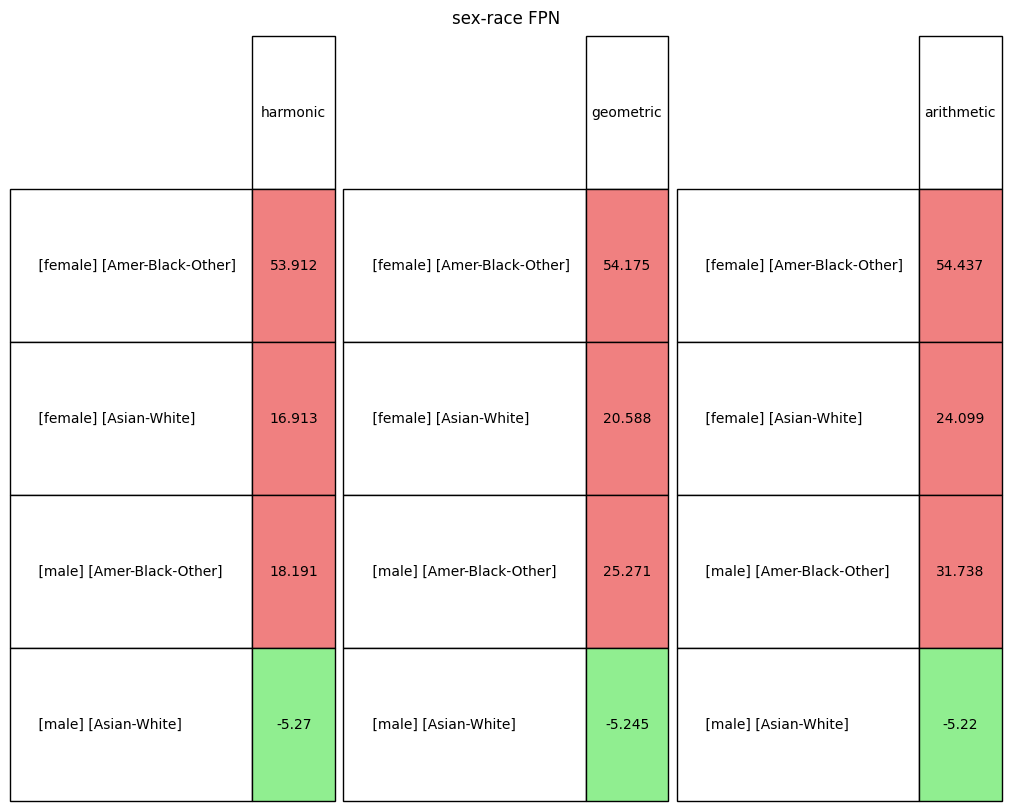

{'00': 99.99999999999999,
 '01': 15.836526181353772,
 '10': 9.329268292682908,
 '11': -6.393389438123403}

'sex':{
        0: 'female',
        1: 'male'
    },
    'race':{
        0: 'Amer-Black-Other',
        1: 'Asian-White'
    }

XGB: {'00': 20.5762987012987,
  '01': 18.601825818320656,
  '10': 30.82368082368083,
  '11': -6.561270689527191}

---

# Model 2: Fairness metrics and penalty after reweighting

To compute penalties for Model 2:
- **Actual value**: Fairness metric for `sex-race` using Model 2's predictions
- **Predicted value**: Harmonic mean of `sex` and `race` metrics using Model 2's predictions

In [51]:
from sklearn.ensemble import RandomForestClassifier

In [131]:
def compute_penalties_after_reweighting_multilambda(weights_dict):
  m = 'PPE'
  for lambda_ in lambdas:

    print(f"------- LAMBDA: {lambda_} ---------")
    # Train Model 2 with weights and get predictions on test set
    sensible_attribute = 'sex-race'
    # model_2 = RandomForestClassifier(random_state=1234).fit(
    #     X_train['sex-race'], 
    #     y_train['sex-race'], 
    #     sample_weight = weights_per_metric['ppe']  # Change this to use different weights
    # )
    # y_pred_model2_test = model_2.predict(X_test['sex-race'])

    import xgboost as xgb
    # Convert string combinations to numeric codes for BOTH train and val
    X_train_numeric = X_train['sex-race'].copy()
    X_train_numeric['sex-race'] = X_train_numeric['sex-race'].astype('category').cat.codes

    X_test_numeric = X_test['sex-race'].copy()
    X_test_numeric['sex-race'] = X_test_numeric['sex-race'].astype('category').cat.codes

    model_2 = xgb.XGBClassifier(random_state = 1234, eval_metric='logloss')
    model_2.fit(X_train_numeric, y_train['sex-race'], sample_weight=weights_dict[lambda_])
    y_pred_model2_test = model_2.predict(X_test_numeric)


    attrs = ['sex', 'race', 'sex-race']

    df_original = pd.read_csv(dataset_path)

    fairness_metrics_model2 = {}
    count_groups_model2 = {}

    # First, compute metrics for the COMBINED attribute (actual values)
    # Create df with combined column for indexing
    df_combined = df_original.copy()


    for attr in attrs:
        individual_attrs = attr.split('-')
        if len(attr) > 1:
            df_original[attr] = reduce(lambda x, y: x.astype(str) + y.astype(str), [df_combined[col] for col in individual_attrs])
        # DO I NEED TO DO A DROP HERE?

        
        sensible_indexes_individual = df_original[attr].loc[list(X_test[attr].index)]
        cm_dict_individual = compute_cm_group(
          df_original, attr, sensible_indexes_individual,
          y_pred_model2_test, y_test[attr], X_test[attr], target_variable_labels
        )
        
        fairness_metrics_model2[attr] = {}
        for m in fair_metrics:
          fairness_metrics_model2[attr][m], count_groups_model2[attr] = compute_fairness_metrics_and_counts(cm_dict_individual, m, attr, mapping, dataset_path)
    
    print(compute_penalty_2(fairness_metrics_model2, df_combined, 'sex', 'race', m))

Comparing penalties after reweighting and before

In [ ]:
# Currently on FPN
compute_penalties_after_reweighting_multilambda(weights_notsized_dict)

------- LAMBDA: 0.1 ---------
({'00': 58.17495512617464, '01': 20.765272865501593, '10': 7.451673248804824, '11': -15.467076086792284}, {'00': 58.91375028886669, '01': 28.955497632540375, '10': 28.29526788373778, '11': -15.097748545698854}, {'00': 59.6394954167276, '01': 36.29912666863468, '10': 44.44449955656784, '11': -14.729602318251116})
------- LAMBDA: 1.0 ---------
({'00': 46.12878410787818, '01': 29.585283421262247, '10': 13.673053209470059, '11': -18.80005516830583}, {'00': 46.205471621964016, '01': 42.19901045694142, '10': 35.64539928489306, '11': -18.185890016802414}, {'00': 46.282049968756716, '01': 52.55317986800513, '10': 52.02523908032891, '11': -17.574899938179122})
------- LAMBDA: 5.0 ---------
({'00': 46.12878410787818, '01': 29.92690471682069, '10': 14.022411942580739, '11': -18.984157272414826}, {'00': 46.205471621964016, '01': 42.85660852981943, '10': 36.43119921403371, '11': -18.35885996913868}, {'00': 46.282049968756716, '01': 53.40055729637306, '10': 52.999467365

In [138]:
# Penalties calculated using the TEST set
penalties_ontest_baseline['FPN']

({'00': 100.0,
  '01': 16.86350215761981,
  '10': 9.27551020408162,
  '11': -6.599428408772176},
 {'00': 100.0,
  '01': 22.69546701336668,
  '10': 20.81280251898063,
  '11': -6.5689195182182765},
 {'00': 100.00000000000001,
  '01': 28.11832377626185,
  '10': 30.88291530761444,
  '11': -6.538419359347247})

In [133]:
compute_penalties_after_reweighting_multilambda(weights_sized_dict)

------- LAMBDA: 0.1 ---------
({'00': 49.675324675324674, '01': 29.65486711372162, '10': 7.367839300945181, '11': -18.57463432334204}, {'00': 49.67982638157531, '01': 42.33234625054437, '10': 28.118872212230826, '11': -17.929593971500456}, {'00': 49.68432768513366, '01': 52.725111851828025, '10': 44.221353652454276, '11': -17.288062608388856})
------- LAMBDA: 1.0 ---------
({'00': 49.675324675324674, '01': 30.62663937048173, '10': 8.544591046130892, '11': -19.11563547293468}, {'00': 49.67982638157531, '01': 44.227751126372745, '10': 30.6359161492004, '11': -18.439914355840305}, {'00': 49.68432768513366, '01': 55.16227387291534, '10': 47.39101619579814, '11': -17.76802648050529})
------- LAMBDA: 5.0 ---------
({'00': 60.04645760743321, '01': 31.535144120178135, '10': -20.7106399685905, '11': -17.745059456289415}, {'00': 62.386548435983705, '01': 45.65226395113252, '10': -8.034659679959603, '11': -16.835030138298748}, {'00': 64.58957945061178, '01': 56.858502429012134, '10': 3.3101995383

In [ ]:
# Penalties calculated using the validation set
penalties_across_metrics['PPE']['sex-race']

{'00': 59.335539012958364,
 '01': 28.29550646593365,
 '10': 7.360977177756338,
 '11': -26.05579574311748}

{'00': 59.335539012958364,
 '01': 28.29550646593365,
 '10': 7.360977177756338,
 '11': -26.05579574311748}

---

# Attempting to solve Penalty issues from Model 1

What is happening with the penalties: As you can see in the next cell, the FNs for subgroup 00 is 0 which makes the penalty be 100%. This isn't bad, but its also not the best. The penalty is however successfully mitigated. 

In [ ]:
cm_dict

{'01': array([[1144,   22],
        [  80,   77]]),
 '00': array([[264,   0],
        [ 14,   9]]),
 '11': array([[1782,  237],
        [ 292,  681]]),
 '10': array([[222,   8],
        [ 32,  21]])}

In [ ]:
fairness_metrics_ontest

{'FPN': {'01': 0.21568627450980393,
  '00': 0,
  '11': 0.44801512287334594,
  '10': 0.2},
 'PPE': {'01': 0.018867924528301886,
  '00': 0,
  '11': 0.11738484398216939,
  '10': 0.034782608695652174}}

In [ ]:
penalties_ontest_baseline['FPN']['harmonic']

{'00': 100.0,
 '01': 16.86350215761981,
 '10': 9.27551020408162,
 '11': -6.599428408772176}

In [ ]:
"""
if FP!=0:
      if m=='PPE':
        fairness_metric = (FP)/(TN+FP) #PredictiveEquality or FalsePositiveRate (FPR)
      elif m=='FPR':
        fairness_metric = (FP)/(TP+FP) #FalsDiscoveryRate
      elif m=='FPP':
        fairness_metric= (FP)/len_group #FalsePositiveParity
      elif m=='FPN':
        fairness_metric= (FP)/(FN+FP)
    if FN!=0:
      if m=='FPA':
        fairness_metric= (FN)/(TN+FN) #FORParity
      elif m=='EOP':
        fairness_metric= (FN)/(TP+FN) #EqualOpportunity
      elif m=='FNP':
        fairness_metric= (FN)/len_group #FalseNegativeParity
      elif m=='FNE':
        fairness_metric=(FN)/(FP+FN)
    if FP!=0 and FN!=0:
      if m=='ERR':
        fairness_metric= (FP+FN)/len_group #ErrorRate
    if TP!=0:
      if m=='GFA':
        fairness_metric = (TP+FP)/len_group #Group Fairness
      elif m=='PPA':
        fairness_metric = (TP)/(TP+FP) #Predictive Parity
      elif m=='OAE':
        fairness_metric= (TP+TN)/len_group #OverallAccuracyEquality
"""

In [117]:
# values= {}
attrs_for_penalty = ['sex', 'race', 'sex-race']
penalties_across_metrics_DEBUG= {}
for m in fair_metrics:
  # print(m)
  df=pd.read_csv(dataset_path)
  # actual_values= {}
  # predicted_values= {}
  # for i in range(1, len(protected_attributes)+1):
  for sensible_attribute in attrs_for_penalty:
    s = sensible_attribute.split('-')
    #print(sensible_attribute)
    if len(s)==2:
      s1, s2 = sensible_attribute.split('-')
      # Build dictionary for attribute combinations. Form {attributes: {subgroup: value, s: v, s: v, ...}...}
      actual_values[sensible_attribute], predicted_values[sensible_attribute] = actual_predicted_values_2(fairness_metrics_ontest_full, df,s1, s2, m)
      # print(s1, s2, actual_values[sensible_attribute], predicted_values[sensible_attribute])

      # Build dictionary for penalty calculation of each attribute and subgroup combination. 
      penalties[sensible_attribute] = compute_penalty(actual_values[sensible_attribute], predicted_values[sensible_attribute])
      # print(penalties[sensible_attribute])
    
    # values[m]= [actual_values, predicted_values]
    penalties_across_metrics_DEBUG[m]= penalties # The penalties dictionary itself didn't include m before


#print(values['FPP'])


In [126]:
penalties_ontest_baseline['PPE']

({'00': 100.0,
  '01': 27.07802141764407,
  '10': -23.355811889973385,
  '11': -26.05306401103472},
 {'00': 100.0,
  '01': 46.655991786689434,
  '10': 17.188182287262762,
  '11': -24.717830878834953},
 {'00': 100.0,
  '01': 60.97770154373928,
  '10': 44.40637171595612,
  '11': -23.396741373617306})

In [124]:
penalties_across_metrics_DEBUG['PPE']['sex-race']

{'00': 100.0,
 '01': 25.30139468914979,
 '10': -19.60049037282757,
 '11': -18.9260716571641}

In [127]:
penalties_ontest_baseline['FPN']

({'00': 100.0,
  '01': 16.86350215761981,
  '10': 9.27551020408162,
  '11': -6.599428408772176},
 {'00': 100.0,
  '01': 22.69546701336668,
  '10': 20.81280251898063,
  '11': -6.5689195182182765},
 {'00': 100.00000000000001,
  '01': 28.11832377626185,
  '10': 30.88291530761444,
  '11': -6.538419359347247})

In [128]:
penalties_across_metrics_DEBUG['FPN']['sex-race']

{'00': 100.0,
 '01': 25.30139468914979,
 '10': -19.60049037282757,
 '11': -18.9260716571641}